## Build a basic chatbot with langgraph (Graph API) ##

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    #messages have the type "list".the add_messages function
    #int hte annotation defines how this state key should e updated
    #(in this case, it apends messages to the list, rather than overwriting them)
    messages:Annotated[list, add_messages]

graph_builder=StateGraph(State)

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
from langchain_groq import ChatGroq 
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [7]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000029196EA17F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029196EA2510>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000029196FC8050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029196FC8A50>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [9]:
##Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [10]:
graph_builder=StateGraph(State)

##adding nodes
graph_builder.add_node("llmchatbot",chatbot)

##adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile this graph
graph = graph_builder.compile()

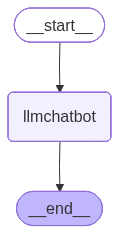

In [11]:
## visualise the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
response = graph.invoke({"messages":"Hi"})

In [13]:
response["messages"][-1].content

'How can I help you today?'

In [14]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here to help you with any questions or topics you'd like to discuss. How can I assist you today?


## Tool Calling Chatbot ##

In [15]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langraph?")

{'query': 'what is langraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [16]:
## Custom function
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: First integer.
        b: Second integer.

    Returns:
        Product of a and b.
    """
    return a * b

In [17]:
tools = [tool,multiply]

In [18]:
llm_with_tool = llm.bind_tools(tools)

In [19]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000029196FC8050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029196FC8A50>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool deliver

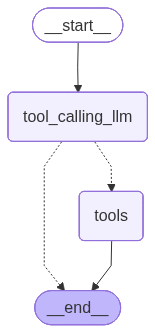

In [20]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## grpah
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

# if the latest message (result) from assistant is a tool call -> tool_condition routes to tool
# if the latest message (result) from assistant is a not a tool call -> tools_condition routes to end
    tools_condition
)
builder.add_edge("tools",END)

##compile the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
response = graph.invoke({"messages":"what is the recent AI news?"})

In [22]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.politico.com/news/2026/06/15/trumps-newest-fight-with-anthropic-00962858", "title": "Trump promised to bring order to AI oversight. That lasted 2 weeks. - Politico", "score": 0.70336664, "published_date": "Tue, 16 Jun 2026 02:30:00 GMT", "content": "New restrictions on Anthropic are causing industry advocates to worry the White House’s plan for a laissez-faire approach to the technology is crumbling. And they’re undercutting the president’s promise of a light-touch approach to regulating advanced AI, according to tech industry representatives, policy experts and at least one administration official. Asked about whether the new export control directive undermined the president’s recent AI executive order, White House spokesperson Kush Desai said the Trump administration “is collaborating with AI industry leaders to balance cutting-edge innovation with national securit

In [23]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (s5545353s)
 Call ID: s5545353s
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.politico.com/news/2026/06/15/trumps-newest-fight-with-anthropic-00962858", "title": "Trump promised to bring order to AI oversight. That lasted 2 weeks. - Politico", "score": 0.70336664, "published_date": "Tue, 16 Jun 2026 02:30:00 GMT", "content": "New restrictions on Anthropic are causing industry advocates to worry the White House’s plan for a laissez-faire approach to the technology is crumbling. And they’re undercutting the president’s promise of a

In [24]:
response = graph.invoke({"messages":"What is 2 multiply by 5?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 5?
================================== Ai Message ==================================
Tool Calls:
  multiply (na97bnq8q)
 Call ID: na97bnq8q
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: multiply

10


In [25]:
response = graph.invoke({"messages":"What is 2 multiply by 5 and them multiply by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiply by 5 and them multiply by 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (f0twkyxv9)
 Call ID: f0twkyxv9
  Args:
    a: 2
    b: 5
  multiply (m64s3e68y)
 Call ID: m64s3e68y
  Args:
    a: 35
    b: 7
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

245


In [26]:
response = graph.invoke({"messages":"Give me the recent news of ongoing war between USA and Iran and then multiply by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent news of ongoing war between USA and Iran and then multiply by 7?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qzs06r275)
 Call ID: qzs06r275
  Args:
    query: USA and Iran war news
    start_date: 2024-01-01
    topic: news
  tavily_search (vrm8q12te)
 Call ID: vrm8q12te
  Args:
    a: 7
    b: 3
    query: result of 7 * 3
================================= Tool Message =================================
Name: tavily_search

{"query": "USA and Iran war news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.usatoday.com/story/news/2026/03/03/texas-primary-iran-israel-austin-shooting-epstein-guthrie-nasa-moon-jim-carrey/88957147007/", "title": "Daily Briefing: What are your Iran war questions? - USA Today", "score": 0.77096564, "published_date": "Tue, 03 Mar 2026 11:36:00 GMT", "con

## ReAct Agent ##

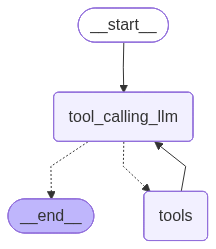

In [27]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## grpah
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

# if the latest message (result) from assistant is a tool call -> tool_condition routes to tool
# if the latest message (result) from assistant is a not a tool call -> tools_condition routes to end
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

##compile the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
response = graph.invoke({"messages":"Give me the recent news of ongoing war between USA and Iran and then multiply by 7?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Give me the recent news of ongoing war between USA and Iran and then multiply by 7?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (vd4g4t6ej)
 Call ID: vd4g4t6ej
  Args:
    query: USA vs Iran war news
    start_date: 2024-05-01
    time_range: day
    topic: news
  multiply (3fv5s3qqm)
 Call ID: 3fv5s3qqm
  Args:
    a: 10
    b: 7
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================= Tool Message =================================
Name: multiply

70
================================== Ai Message ==================================

The function call for `tavily_search` failed because it's not possible to set both `start_date` and `time_range` at the same time. The `tim

## Adding memory in Agentic Graph ##

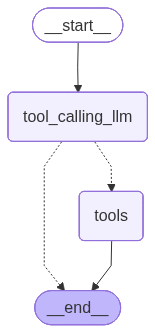

In [29]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## grpah
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

##adding edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",

# if the latest message (result) from assistant is a tool call -> tool_condition routes to tool
# if the latest message (result) from assistant is a not a tool call -> tools_condition routes to end
    tools_condition
)
builder.add_edge("tools",END)

##compile the graph
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## Streaming ##

In [30]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [31]:
def superbot(state:State):
    return {"message":[llm.invoke(state["messages"])]}

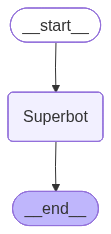

In [32]:
graph = StateGraph(State)

##node
graph.add_node("Superbot",superbot)
##edges

graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

graph_builder=graph.compile(checkpointer=memory)

##display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [33]:
##Invocation

config = {"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi my name is K and i like cricket"},config)

{'messages': [HumanMessage(content='Hi my name is K and i like cricket', additional_kwargs={}, response_metadata={}, id='0c7f2f40-3501-43af-8a68-7d6a06b24110')]}

In [34]:
#create a thread
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"Hi, my name is K and i like cricket ver much."},config, stream_mode = "updates"):
    print(chunk)

{'Superbot': None}


In [36]:
for chunk in graph_builder.stream({"messages":"Hi, my name is K and i like cricket ver much."},config, stream_mode = "values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is K and i like cricket ver much.', additional_kwargs={}, response_metadata={}, id='e1396285-813e-484d-998a-ff8f4dd87e05'), HumanMessage(content='Hi, my name is K and i like cricket ver much.', additional_kwargs={}, response_metadata={}, id='f67da176-8fe9-4635-b356-9baa6dfb93c5'), HumanMessage(content='Hi, my name is K and i like cricket ver much.', additional_kwargs={}, response_metadata={}, id='e07d9c6a-8ef1-44dd-8385-2be679660611')]}


In [ ]:
#create a thread
config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"Hi, my name is K and i like cricket very much."},config, stream_mode = "updates"):
    print(chunk)

{'Superbot': None}


In [39]:
for chunk in graph_builder.stream({"messages":"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is O and i like hockey', additional_kwargs={}, response_metadata={}, id='5d1c745b-151b-411f-bbbf-4772c3ff529c'), HumanMessage(content='Hi, my name is K and i like cricket ver much.', additional_kwargs={}, response_metadata={}, id='9b0be486-ddb4-483a-9692-722a36c7c00d'), HumanMessage(content='I also like football', additional_kwargs={}, response_metadata={}, id='c6f09281-3fa6-4e10-bc64-32c2d58edecb')]}


In [41]:
config = {"configurable":{"thread_id":"5"}}

async for event in graph_builder.astream_events({"messages":"Hi, my name is Krish and i like to cricket very much."},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my name is Krish and i like to cricket very much.'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ecf75-c219-7df0-9b74-f91c16f7b9a7', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Krish and i like to cricket very much.', additional_kwargs={}, response_metadata={}, id='e4324392-2f9b-458c-90ba-24f223ab6738'), HumanMessage(content='Hi, my name is Krish and i like to cricket very much.', additional_kwargs={}, response_metadata={}, id='e4c6afa8-d25f-4696-9a37-12cc230dfa3a')]}}, 'name': 'Superbot', 'tags': ['graph:step:4'], 'run_id': '019ecf75-c21b-7d60-8d71-5db5e5b7ec9c', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 4, 'langgraph_node': 'Superbot', 'langgraph_triggers': ('branch:to:Superbot',), 'langgraph_path': ('__pregel_pull', 'Superbot'), 'langgraph_checkpo